# ANÁLISE EXPLORATÓRIA DOS DADOS + TREINAÇÃO E TESTE DO MODELO DE CLASSIFICAÇÃO

---

**Este notebook apresenta uma análise exploratória dos dados ESG SILVER (dados previamente tratados), com o objetivo de compreender o comportamento das variáveis e subsidiar a definição do modelo mais adequado para implementação em produção (deploy).**

---

**DICIONÁRIO BASE SILVER:**

| Coluna              | Descrição                                         | Tipo               | Valores possíveis / Exemplo |
|---------------------|-------------------------------------------------|--------------------|-----------------------------|
| name                | Nome da empresa                                  | String             | Walt Disney Co              |
| exchange            | Bolsa de valores onde a empresa está listada     | String             | NEW YORK STOCK EXCHANGE, INC. |
| environment_level   | Nível de desempenho ambiental                    | Categórico (ordinal) | Low, Medium, High → Ex: High |
| social_level        | Nível de desempenho social                       | Categórico (ordinal) | Low, Medium, High → Ex: Medium |
| governance_level    | Nível de governança corporativa                 | Categórico (ordinal) | Low, Medium, High → Ex: Medium |
| total_level         | Classificação ESG geral da empresa               | Categórico (ordinal) | Low, Medium, High → Ex: High |

- IMPORTS
---

In [86]:
# Manipulação e plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
pd.set_option("display.max_columns", None)

# Divisão de dados
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
)

# Modelos ML
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

- ANÁLISE EXPLORATÓRIA DOS DADOS
---

In [67]:
df = pd.read_csv("../data/silver/esg_reporting_silver.csv")
display(df.head())
df.info()

,name,exchange,environment_score,social_score,governance_score,total_level
0,Walt Disney Co,"NEW YORK STOCK EXCHANGE, INC.",510,316,321,High
1,General Motors Co,"NEW YORK STOCK EXCHANGE, INC.",510,303,255,High
2,WW Grainger Inc,"NEW YORK STOCK EXCHANGE, INC.",255,385,240,Medium
3,Mohawk Industries Inc,"NEW YORK STOCK EXCHANGE, INC.",570,298,303,High
4,Live Nation Entertainment Inc,"NEW YORK STOCK EXCHANGE, INC.",492,310,250,High


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               722 non-null    object
 1   exchange           722 non-null    object
 2   environment_score  722 non-null    int64 
 3   social_score       722 non-null    int64 
 4   governance_score   722 non-null    int64 
 5   total_level        722 non-null    object
dtypes: int64(3), object(3)
memory usage: 34.0+ KB


In [68]:
# Tratamentos iniciais para analise
classes = {
    "Medium": 0,
    "High": 1,
}
df["total_level_encoded"] = df.total_level.map(classes)

df = pd.get_dummies(
    data=df,
    columns=["exchange"],
    dtype=int
)
df.head()

,name,environment_score,social_score,governance_score,total_level,total_level_encoded,exchange_NASDAQ NMS - GLOBAL MARKET,"exchange_NEW YORK STOCK EXCHANGE, INC."
0,Walt Disney Co,510,316,321,High,1,0,1
1,General Motors Co,510,303,255,High,1,0,1
2,WW Grainger Inc,255,385,240,Medium,0,0,1
3,Mohawk Industries Inc,570,298,303,High,1,0,1
4,Live Nation Entertainment Inc,492,310,250,High,1,0,1


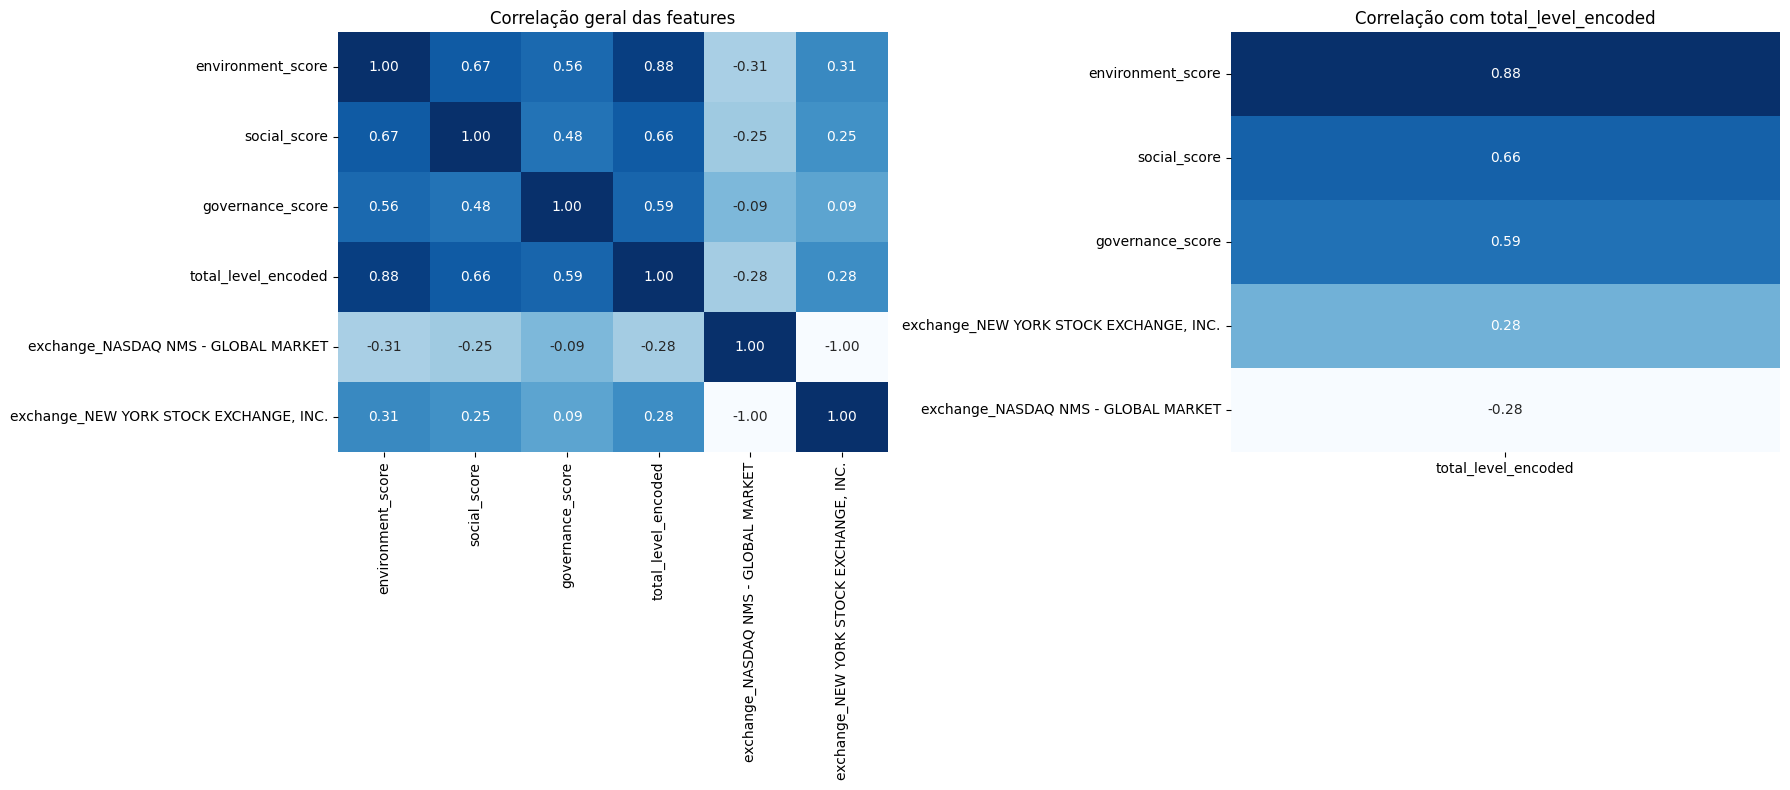

In [69]:
# Análise de correlação
df_corr = df.drop(columns=["name"])

corr_matrix = df_corr.corr(numeric_only=True)

target_corr = corr_matrix["total_level_encoded"].drop("total_level_encoded")
target_corr = target_corr.sort_values(ascending=False)
heatmap_data = target_corr.to_frame()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1) Heatmap 
sns.heatmap(
    corr_matrix,
    annot=True, 
    fmt=".2f",
    cmap="Blues",
        cbar=False,
    ax=axes[0]
)
axes[0].set_title("Correlação geral das features")

# 2) Correlação com target
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
    ax=axes[1]
)
axes[1].set_title("Correlação com total_level_encoded")

plt.tight_layout()
plt.show()

**Análise:** O destaque mais forte é a relação entre **environment_score** e **total_level_encoded**, indicando que o componente ambiental é o principal driver do score ESG total nesse dataset. Porém, os pilares social e governança não ficam pra trás, com uma correlação acima de 59. Isso sugere que as empresas geralmente prezam por fatores ambientais do que social e governamental.

Outro ponto importante é a correlação perfeita negativa entre as dummies das exchanges, o que indica claramente o dummy trap, ou seja, uma coluna é completamente redundante em relação à outra. Com esse detalhe analisando, para o treino do modelo, irei dropar uma das colunas entre esse dummy criado para não causar confusão no modelo.

Em resumo: as features tem ótima correlação com o score total, o que faz sentido, pois, provavelmente é a partir desses scores que conseguimos identificar a maturidade ESG de uma empresa.

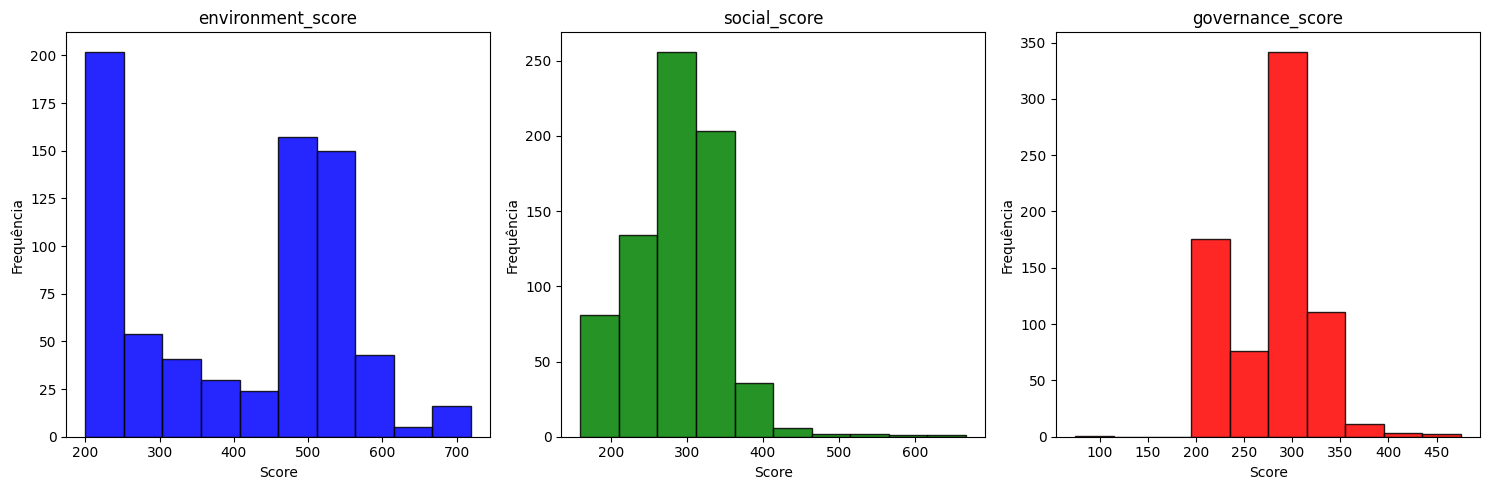

In [70]:
# Análise de destribuição dos pilares esg
cols = [
    "environment_score",
    "social_score",
    "governance_score"
]

colors = ["blue", "green", "red"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(
        df[col].dropna(),
        bins=10,
        color=colors[i],
        alpha=0.85,
        edgecolor="black"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [71]:
df[["environment_score",
    "social_score",
    "governance_score"]].describe()

,environment_score,social_score,governance_score
count,722.000000,722.000000,722.000000
mean,404.806094,292.182825,278.761773
std,145.103870,57.017406,47.031536
min,200.000000,160.000000,75.000000
25%,240.000000,243.000000,235.000000
50%,483.000000,302.000000,300.000000
75%,518.750000,322.750000,310.000000
max,719.000000,667.000000,475.000000


**Análise:** Os histogramas revelam distribuições distintas entre os três pilares ESG. O `environment_score` apresenta um comportamento bimodal, com uma concentração de empresas na faixa baixa (~200–250) e outro grupo expressivo na faixa média-alta (~500–600). Isso indica que as empresas tendem a se polarizar no desempenho ambiental, com poucas no meio-termo.

O `social_score` tem uma distribuição mais concentrada e aproximadamente normal, com pico em torno de 300–350 e cauda longa à direita. A maioria das empresas apresenta desempenho social similar, com poucos outliers de alta performance.

O `governance_score` é o mais concentrado dos três, com a grande maioria das empresas agrupada entre 250 e 320. Isso indica baixa variabilidade na dimensão de governança. As empresas são mais homogêneas nesse pilar.

Em resumo, o componente ambiental é o que mais diferencia as empresas entre si, enquanto governança apresenta menor poder discriminatório no dataset. Esse padrão é consistente com a análise de correlação anterior, onde environment se destacou como principal driver do score ESG total.

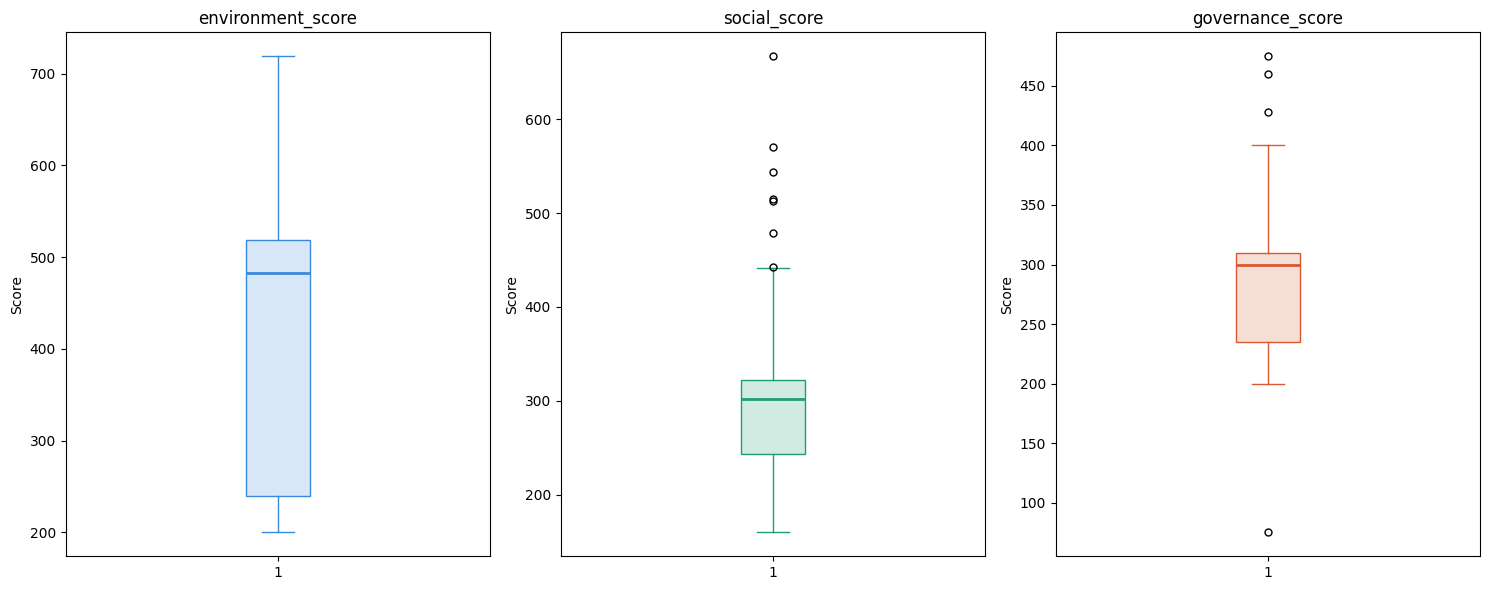

In [88]:
# aNálise de outliers
cols = ["environment_score", "social_score", "governance_score"]
colors = ["#378ADD", "#1D9E75", "#D85A30"]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color+"33", color=color),
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color),
                    flierprops=dict(marker='o', color='#E24B4A', markersize=5))
    axes[i].set_title(col)
    axes[i].set_ylabel("Score")

plt.tight_layout()
plt.show()

**Análise:** Os três pilares têm escalas diferentes, o que reforça a necessidade de normalização antes de treinar qualquer modelo, ainda mais que usaremos KNN, que é baseado em distancia. Os outliers de social_score e governance_score merecem atenção, vale investigar se são erros de dados ou empresas genuinamente atípicas antes de decidir se remove ou mantém.

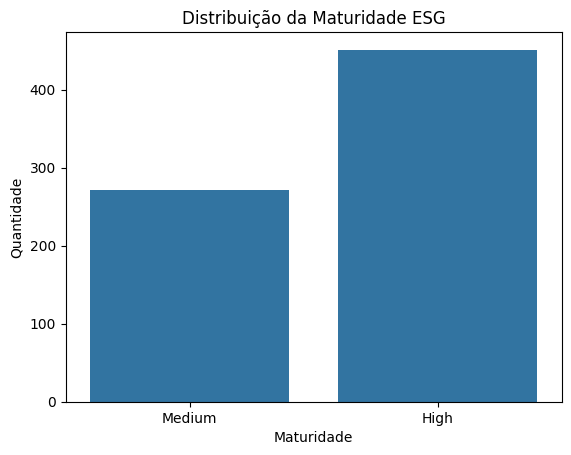

In [72]:
# Análise de desbalanceamento da target (total_level)
target_distribuition = df.total_level.value_counts().sort_values(ascending=True)

sns.barplot(target_distribuition)
plt.title("Distribuição da Maturidade ESG")
plt.xlabel("Maturidade")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

**Análise:** Como visto antes, é possível identificar que na base só existe duas classes registradas: Medium e High. Ou seja, não há nenhuma empresa com maturidade ESG Low ou Excelent. Isso pode ser um problema para previsões futuras, já que o modelo não terá informações para treino sobre as classes baixa ou excelente. 

Após entender melhor sobre meu conjunto de dados, irei partir para a construção do modelo de previsão. Farei todas as etapas e testes necessários para a criação do modelo:
- *Divisão dos dados* 
- *Criação de modelos*
- *Treinos e Testes* 
- *Validando com métricas apropriadas*  

- CRIAÇÃO E VALIDAÇÃO DE MODELO ML (PREVISÃO MATURIDADE ESG)
---

Para iniciar a avaliação do modelo de classificação desenvolvido, a base de dados será dividida em dois subconjuntos: treino e teste. Essa separação é fundamental para que o modelo seja treinado em uma parte dos dados e avaliado em outra ainda não vista, permitindo uma estimativa mais realista de seu desempenho em cenários reais.

Na etapa de validação, serão utilizadas duas abordagens: Holdout e Stratified K-Fold Cross Validation. A técnica Holdout consiste em separar uma parcela fixa dos dados exclusivamente para teste, oferecendo uma avaliação simples e objetiva do modelo. Já o Stratified K-Fold realiza múltiplas divisões da base em subconjuntos, preservando a proporção das classes em cada partição. Essa estratégia reduz a dependência de uma única divisão dos dados e proporciona uma avaliação mais robusta e confiável, especialmente em problemas de classificação com possíveis desbalanceamentos entre classes.

Para os modelos, serão utilizados 3 algoritmos preditivos de classificação:
- `XGBoost` -> Modelo ensemble baseado em gradient boosting de árvores de decisão
- `K-Nearest Neighbors` -> Modelo baseado em distancia (euclidiana, manhattan...)
- `Decision Tree` -> Modelo baseado em árvore de decisão

O desempenho do modelo será analisado por meio das métricas **Matriz de Confusão**, **Acurácia**, **Precisão** e **Recall**. A matriz de confusão permitirá visualizar os acertos e erros de classificação em cada classe, enquanto as demais métricas fornecerão uma visão quantitativa da capacidade do modelo em realizar previsões corretas e identificar corretamente os exemplos positivos.

In [73]:
# Utilizando base gold para treinamento de modelo 
df_gold = pd.read_csv("../data/gold/esg_reporting_gold.csv")
df_gold.head()

,environment_score,social_score,governance_score,total_level,exchange_nasdaq nms - global market
0,510,316,321,1,0
1,510,303,255,1,0
2,255,385,240,0,0
3,570,298,303,1,0
4,492,310,250,1,0


In [74]:
# Divisão de dados de treino e teste
df_train, df_test = train_test_split(df_gold, test_size=0.1, random_state=42)
print("df_train: ", df_train.shape)
print("df_test: ", df_test.shape)

df_train:  (649, 5)
df_test:  (73, 5)


In [75]:
# Analisando balanceamento da target nas duas bases
print("Balanceamento da target - df_train\n", df_train.total_level.value_counts(), "\n")
print("Balanceamento da target - df_test\n", df_test.total_level.value_counts())

Balanceamento da target - df_train
 total_level
1    406
0    243
Name: count, dtype: int64 

Balanceamento da target - df_test
 total_level
1    45
0    28
Name: count, dtype: int64


In [76]:
# Divisão x e y 
x = df_train.drop("total_level", axis=1)
y = df_train.total_level

In [ ]:
# Criação dos modelos
xgb = XGBClassifier(
    n_estimators=20,
    max_depth=6,
    learning_rate=0.3

)
knn = KNeighborsClassifier(
    n_neighbors=5,
)
tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=3
)

*1° Técnica de divisão de dados - HoldOut*

In [78]:
# Utilizando train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Modelo: XGBoost
Acurácia : 0.9846
Precisão: 0.9850
Recall   : 0.9846
Modelo: Random Forest
Acurácia : 0.9846
Precisão: 0.9850
Recall   : 0.9846
Modelo: Decision Tree
Acurácia : 0.9846
Precisão: 0.9850
Recall   : 0.9846


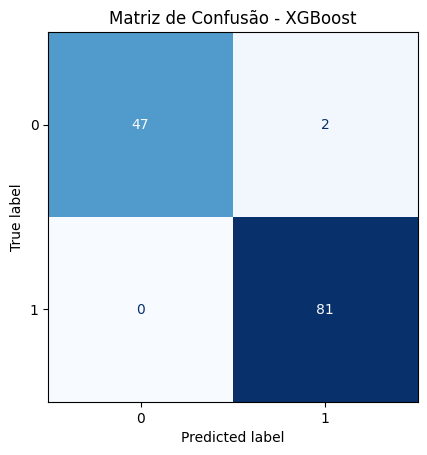

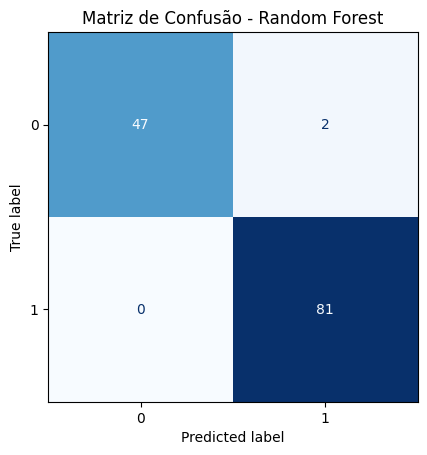

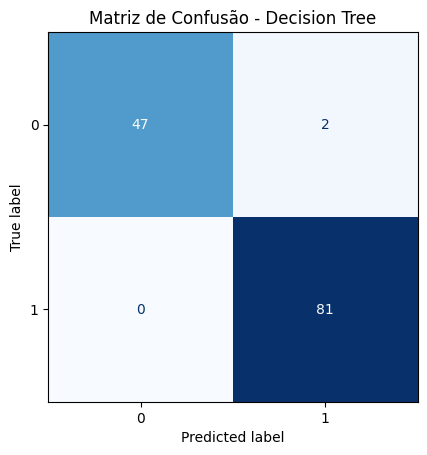

In [79]:
models = {
    "XGBoost": xgb,
    "Random Forest": rf,
    "Decision Tree": tree,
}

for name, model in models.items():

    print("=" * 60)
    print(f"Modelo: {name}")
    print("=" * 60)


    model.fit(x_train, y_train)
    y_pred = model.predict(x_val)

    acc = accuracy_score(y_val, y_pred)
    precision = precision_score(
        y_val,
        y_pred,
        average="weighted"
    )
    recall = recall_score(
        y_val,
        y_pred,
        average="weighted"
    )
    cm = confusion_matrix(y_val, y_pred)

    
    print(f"Acurácia : {acc:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    
    ConfusionMatrixDisplay(cm).plot(
    cmap="Blues", colorbar=False)
    plt.title(f"Matriz de Confusão - {name}");

**Análise:** O desempenho dos 3 modelos foi exatamente igual em todas as métricas. Geralmente isso não é comum. Isso pode estar acontecendo pelo fato do conjunto de dados ser muito simples. Para ver se os modelos não estão decorando os dados, eles irão prever os dados da base de teste.

In [80]:
# Divisão x e y 
x_df_test = df_test.drop("total_level", axis=1)
y_df_test = df_test.total_level

Modelo: XGBoost
Acurácia : 0.9589
Precisão: 0.9590
Recall   : 0.9589


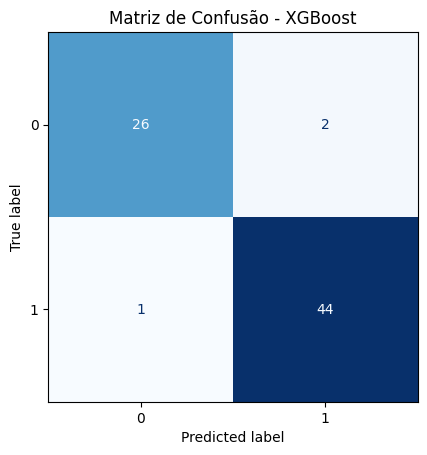

Modelo: Random Forest
Acurácia : 0.9726
Precisão: 0.9726
Recall   : 0.9726


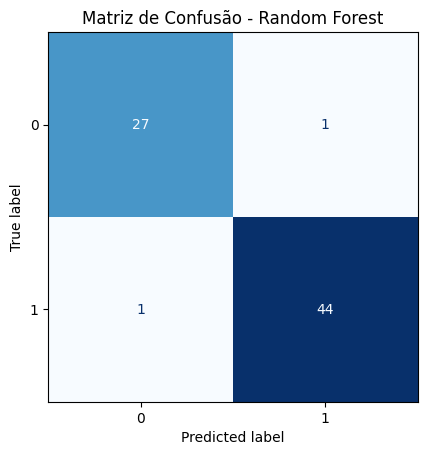

Modelo: Decision Tree
Acurácia : 0.9589
Precisão: 0.9590
Recall   : 0.9589


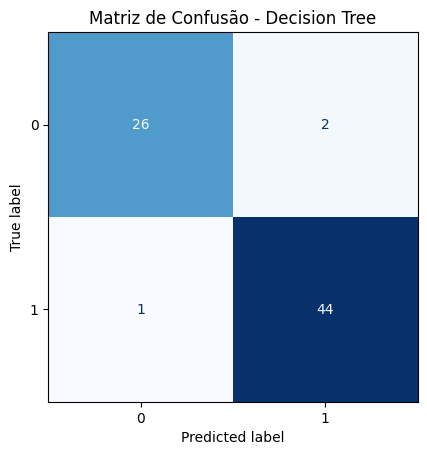

In [81]:
for name, model in models.items():

    print("=" * 60)
    print(f"Modelo: {name}")
    print("=" * 60)

    y_df_test_pred = model.predict(x_df_test)

    acc_df_test = accuracy_score(y_df_test, y_df_test_pred)
    precision_df_test = precision_score(
        y_df_test,
        y_df_test_pred,
        average="weighted"
    )

    recall_df_test = recall_score(
        y_df_test,
        y_df_test_pred,
        average="weighted"
    )

    cm_df_test = confusion_matrix(y_df_test, y_df_test_pred)

    print(f"Acurácia : {acc_df_test:.4f}")
    print(f"Precisão: {precision_df_test:.4f}")
    print(f"Recall   : {recall_df_test:.4f}")

    ConfusionMatrixDisplay(cm_df_test).plot(
        cmap="Blues",
        colorbar=False
    )

    plt.title(f"Matriz de Confusão - {name}")
    plt.show()

In [82]:
# Utilizando base gold para treinamento de modelo 
df_bronze = pd.read_csv("../data/bronze/esg_reporting_bronze.csv")
df_bronze.head()

,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,Medium,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,Medium,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,Medium,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,Medium,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,Medium,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258
